# 06 — Gradient Boosting Classifier
## Model-Specific Feature Engineering · Training · Hyperparameter Tuning · Evaluation

---

### Notebook Overview

This notebook covers the full pipeline for a **Gradient Boosting** model:

| Step | Description |
|------|-------------|
| 1 | Environment setup & imports |
| 2 | Data loading & quick sanity check |
| 3 | Model-specific feature adjustments (interaction & transform features) |
| 4 | Feature matrix construction |
| 5 | Baseline model training |
| 6 | Hyperparameter tuning (learning rate, n_estimators / max_iter, max_depth) |
| 7 | Evaluation — accuracy, precision, recall, F1, confusion matrix |
| 8 | Cross-validation |
| 9 | Feature importance (permutation-based) |
| 10 | Prediction visualizations |
| 11 | Outside detection |
| 12 | Interpretation & conclusions |

**Algorithm choice:** `HistGradientBoostingClassifier` (scikit-learn) — a histogram-based GBM  
that handles large datasets efficiently and supports missing values natively.  
It maps 1-to-1 with the `n_estimators / max_depth / learning_rate` knobs of classical GBMs  
(via `max_iter`, `max_depth`, `learning_rate`).

---

## 1 — Environment Setup & Imports

Install any missing packages, then import every library needed for the  
full pipeline.  All random seeds are fixed at **42** for reproducibility.


In [4]:
import subprocess, sys

def pip_install(*packages):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages]
    )

pip_install("scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "joblib")
print("All packages ready.")


All packages ready.


In [5]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.right": False, "axes.spines.top": False})

print("Imports complete.  NumPy", np.__version__, "| pandas", pd.__version__)


C:\Users\sirin\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\sirin\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Imports complete.  NumPy 1.26.4 | pandas 3.0.0


---
## 2 — Data Loading

We look for pre-processed train / validation / test CSV files produced by  
an earlier feature-engineering notebook.  The loader tries several common  
naming conventions so the notebook works across different project layouts.

> **If your files live elsewhere** set `PROCESSED` to the correct directory  
> or pass the absolute paths directly to `pd.read_csv()`.


In [6]:
NOTEBOOK_PATH = Path.cwd()
PROJECT_ROOT  = (NOTEBOOK_PATH / "..").resolve()
PROCESSED     = PROJECT_ROOT / "data" / "processed"

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED}  (exists={PROCESSED.exists()})")


Project root : F:\AmphiLocator-ML
Processed dir: F:\AmphiLocator-ML\data\processed  (exists=True)


In [7]:
def load_first_existing(candidates: list[str | Path]) -> pd.DataFrame | None:
    """Try each path in *candidates* and return the first readable DataFrame.

    Parameters
    ----------
    candidates : list of path-like
        Ordered list of paths to attempt.

    Returns
    -------
    pd.DataFrame or None
        First successfully loaded frame, or None if none exist.
    """
    for path in candidates:
        path = Path(path)
        if path.exists():
            try:
                df = pd.read_csv(path)
                print(f"  ✔ Loaded  {path}  →  {df.shape}")
                return df
            except Exception as exc:
                print(f"  ✘ Skipped {path}  ({exc})")
    return None

print("Loading splits …")

train = load_first_existing([
    PROCESSED / "train_fe_scaled.csv",
    PROCESSED / "train_fe.csv",
    PROCESSED / "train.csv",
    PROCESSED / "train" / "train_ready.csv",
    PROCESSED / "train" / "train.csv",
])

val = load_first_existing([
    PROCESSED / "val_fe_scaled.csv",
    PROCESSED / "val_fe.csv",
    PROCESSED / "val.csv",
    PROCESSED / "val" / "val_ready.csv",
])

test = load_first_existing([
    PROCESSED / "test_fe_scaled.csv",
    PROCESSED / "test_fe.csv",
    PROCESSED / "test.csv",
    PROCESSED / "test" / "test_ready.csv",
])

if train is None:
    print("\n⚠  No processed files found — generating a synthetic demo dataset.")
    from sklearn.datasets import make_classification
    X_raw, y_raw = make_classification(
        n_samples=3000, n_features=15, n_informative=10,
        n_classes=3, random_state=RANDOM_STATE
    )
    cols = [f"feature_{i}" for i in range(X_raw.shape[1])]
    full_df = pd.DataFrame(X_raw, columns=cols)
    full_df["label_enc"] = y_raw
    train, temp = train_test_split(full_df, test_size=0.30, random_state=RANDOM_STATE, stratify=y_raw)
    val, test = train_test_split(temp, test_size=0.50, random_state=RANDOM_STATE, stratify=temp["label_enc"])
    print(f"  Demo splits — train {train.shape} | val {val.shape} | test {test.shape}")

for split_df in [df for df in [train, val, test] if df is not None]:
    if "timestamp" in split_df.columns:
        split_df["timestamp"] = pd.to_datetime(split_df["timestamp"], utc=True, errors="coerce")

print(f"\nFinal shapes — train {train.shape} | val {getattr(val, 'shape', None)} | test {getattr(test, 'shape', None)}")


Loading splits …
  ✔ Loaded  F:\AmphiLocator-ML\data\processed\train\train_ready.csv  →  (4664, 40)
  ✔ Loaded  F:\AmphiLocator-ML\data\processed\val\val_ready.csv  →  (999, 40)
  ✔ Loaded  F:\AmphiLocator-ML\data\processed\test\test_ready.csv  →  (1000, 40)

Final shapes — train (4664, 40) | val (999, 40) | test (1000, 40)


In [8]:
CANDIDATE_TARGETS = ["label_enc", "target_label", "target", "label", "class"]

def detect_target(df: pd.DataFrame, candidates: list[str]) -> str:
    """Return the first column name from *candidates* that exists in *df*."""
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(
        f"No target column found.  Tried: {candidates}.\n"
        f"Available columns: {list(df.columns)}"
    )

raw_target = detect_target(train, CANDIDATE_TARGETS)
print(f"Raw target column detected: '{raw_target}'")

if raw_target != "label_enc" or train["label_enc"].dtype == object:
    le = LabelEncoder()
    train["label_enc"] = le.fit_transform(train[raw_target])
    for split_df in [df for df in [val, test] if df is not None]:
        if raw_target in split_df.columns:
            split_df["label_enc"] = le.transform(split_df[raw_target])
    print(f"Label encoding applied.  Classes: {list(le.classes_)}")
else:
    le = None
    print("Target already integer-encoded — skipping LabelEncoder.")

TARGET_COL = "label_enc"
n_classes  = train[TARGET_COL].nunique()
print(f"\nClass distribution in train:\n{train[TARGET_COL].value_counts().sort_index()}")
print(f"\nNumber of classes: {n_classes}")


Raw target column detected: 'label_enc'
Target already integer-encoded — skipping LabelEncoder.

Class distribution in train:
label_enc
0     201
1    1581
2     188
3     468
4     803
5     505
6      72
7     549
8     297
Name: count, dtype: int64

Number of classes: 9


---
## 3 — Model-Specific Feature Adjustments

Gradient Boosting models are **tree-based**: they natively capture non-linear  
relationships, so the most useful engineered features are:

* **Multiplicative interactions** — expose joint effects the model might not  
  discover with shallow trees (e.g. `dist × accuracy_flag`).
* **Monotone transforms** — `sqrt` compresses right-skewed distance columns  
  and can improve split quality even for deep trees.

> **Why not one-hot encode?** `HistGradientBoostingClassifier` handles  
> integer/float inputs directly and grows splits on ordered thresholds,  
> so categorical encoding is only needed if features are string dtype.


In [9]:
def add_gbm_interactions(df: pd.DataFrame) -> pd.DataFrame:
    """Add multiplicative interaction and monotone-transform features.

    New features added (if source columns exist)
    ─────────────────────────────────────────────
    dist_nearest_x_logacc  : dist_nearest  × log_accuracy
    dist_gap_x_highacc     : dist_gap      × high_accuracy_flag
    dist_nearest_sqrt      : √(dist_nearest)
    dist_2nd_sqrt          : √(dist_2nd)
    dist_gap_sqrt          : √(dist_gap)
    """
    df = df.copy()

    if "dist_nearest" in df.columns and "log_accuracy" in df.columns:
        df["dist_nearest_x_logacc"] = df["dist_nearest"] * df["log_accuracy"]

    if "dist_gap" in df.columns and "high_accuracy_flag" in df.columns:
        df["dist_gap_x_highacc"] = df["dist_gap"] * df["high_accuracy_flag"]

    for col in ["dist_nearest", "dist_2nd", "dist_gap"]:
        if col in df.columns:
            df[f"{col}_sqrt"] = np.sqrt(df[col].clip(lower=0))

    return df

train = add_gbm_interactions(train)
val   = add_gbm_interactions(val)   if val  is not None else None
test  = add_gbm_interactions(test)  if test is not None else None

INTERACTION_COLS = [
    "dist_nearest_x_logacc", "dist_gap_x_highacc",
    "dist_nearest_sqrt", "dist_2nd_sqrt", "dist_gap_sqrt",
]
created = [c for c in INTERACTION_COLS if c in train.columns]
print(f"Interaction / transform features created ({len(created)}):")
for c in created:
    print(f"  {c:<30}  mean={train[c].mean():.4f}  std={train[c].std():.4f}")

if not created:
    print("  (none — source columns absent; proceeding with base features)")


Interaction / transform features created (5):
  dist_nearest_x_logacc           mean=0.0001  std=0.0001
  dist_gap_x_highacc              mean=0.0000  std=0.0000
  dist_nearest_sqrt               mean=0.0049  std=0.0023
  dist_2nd_sqrt                   mean=0.0066  std=0.0020
  dist_gap_sqrt                   mean=0.0041  std=0.0014


---
## 4 — Feature Matrix Construction

We select the numeric predictor columns, append any newly engineered  
interactions, and split each split into `X` (features) and `y` (target).

`NaN` values are left as-is — `HistGradientBoostingClassifier` handles  
missing values natively without imputation.


In [10]:
NON_FEATURE_COLS = {
    "id", "timestamp", "label_enc", "target_label",
    "target", "label", "class", "amphitheatre", "nearest_amphi",
}

def build_feature_list(df: pd.DataFrame, extra_cols: list[str] | None = None) -> list[str]:
    """Derive feature columns from a DataFrame.

    Priority order
    1. A saved feature list in  data/processed/feature_cols.json
    2. All numeric columns excluding obvious non-feature names
    3. Append *extra_cols* (interaction features) if not already included.
    """
    feature_file = PROCESSED / "feature_cols.json"
    if feature_file.exists():
        try:
            saved = json.loads(feature_file.read_text()).get("all_features", [])
            cols  = [c for c in saved if c in df.columns]
            print(f"Loaded {len(cols)} features from {feature_file}")
        except Exception as exc:
            print(f"Could not read feature file ({exc}); falling back to auto-detect.")
            cols = []
    else:
        cols = []

    if not cols:
        cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in NON_FEATURE_COLS
        ]
        print(f"Auto-detected {len(cols)} numeric features.")

    for c in (extra_cols or []):
        if c in df.columns and c not in cols:
            cols.append(c)

    return cols

FEATURES = build_feature_list(train, extra_cols=INTERACTION_COLS)
print(f"\nTotal features used: {len(FEATURES)}")
print("First 20:", FEATURES[:20])

X_train = train[FEATURES]
y_train = train[TARGET_COL]

X_val  = val[FEATURES]  if val  is not None else None
y_val  = val[TARGET_COL] if val  is not None and TARGET_COL in val.columns  else None

X_test = test[FEATURES] if test is not None else None
y_test = test[TARGET_COL] if test is not None and TARGET_COL in test.columns else None

print(f"\nX_train {X_train.shape}  |  y_train {y_train.shape}")
print(f"X_val   {getattr(X_val,  'shape', None)}  |  y_val   {getattr(y_val,  'shape', None)}")
print(f"X_test  {getattr(X_test, 'shape', None)}  |  y_test  {getattr(y_test, 'shape', None)}")


Auto-detected 44 numeric features.

Total features used: 44
First 20: ['accuracy_mean', 'is_outside', 'sample_count', 'dist_Amphi_1', 'dist_Amphi_2', 'dist_Amphi_3', 'dist_Amphi_4', 'dist_Amphi_5', 'dist_Amphi_6', 'dist_Amphi_7', 'dist_Amphi_8', 'dist_nearest', 'dist_2nd', 'dist_gap', 'nearest_amphi_enc', 'log_accuracy', 'accuracy_bin', 'high_accuracy_flag', 'has_seat', 'seat_block_enc']

X_train (4664, 44)  |  y_train (4664,)
X_val   (999, 44)  |  y_val   (999,)
X_test  (1000, 44)  |  y_test  (1000,)


---
## 5 — Baseline Model Training

Before tuning, we fit a **default** `HistGradientBoostingClassifier` to  
establish a reference performance.  This tells us whether tuning is  
actually improving things.


In [11]:
baseline_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

eval_X, eval_y, eval_name = (
    (X_val, y_val, "validation") if X_val is not None
    else (X_test, y_test, "test")
)

if eval_X is not None and eval_y is not None:
    baseline_pred = baseline_model.predict(eval_X)
    baseline_f1   = f1_score(eval_y, baseline_pred, average="macro", zero_division=0)
    baseline_acc  = accuracy_score(eval_y, baseline_pred)
    print(f"Baseline ({eval_name})  →  Accuracy: {baseline_acc:.4f}  |  Macro F1: {baseline_f1:.4f}")
else:
    print("No evaluation split available for baseline check.")


Baseline (validation)  →  Accuracy: 1.0000  |  Macro F1: 1.0000


---
## 6 — Hyperparameter Tuning

We perform a **grid search** over three key knobs:

| Hyperparameter | Role | Grid |
|---|---|---|
| `learning_rate` | Step size per tree (shrinkage) — smaller = more trees needed but better generalisation | 0.01, 0.05, 0.1 |
| `max_iter` | Number of boosting rounds (≡ `n_estimators` in GradientBoostingClassifier) | 100, 200, 300 |
| `max_depth` | Maximum depth of individual trees — controls model complexity | 3, 5, 7 |

**Strategy:** 4-fold stratified cross-validation, scoring = macro F1  
(appropriate for potentially imbalanced multi-class problems).

> **Performance tip:** set `USE_RANDOM_SEARCH = True` below to switch to  
> `RandomizedSearchCV` with more candidates but fewer fits — useful when  
> the dataset is large.


In [12]:
PARAM_GRID = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_iter":      [100, 200, 300],
    "max_depth":     [3, 5, 7],
    "min_samples_leaf": [20, 50],
}

CV_STRATEGY = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
USE_RANDOM_SEARCH = False

base_estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

if USE_RANDOM_SEARCH:
    searcher = RandomizedSearchCV(
        base_estimator, PARAM_GRID,
        n_iter=20,
        cv=CV_STRATEGY, scoring="f1_macro",
        n_jobs=-1, verbose=1, random_state=RANDOM_STATE,
    )
    print("Using RandomizedSearchCV (n_iter=20) …")
else:
    searcher = GridSearchCV(
        base_estimator, PARAM_GRID,
        cv=CV_STRATEGY, scoring="f1_macro",
        n_jobs=-1, verbose=1, refit=True,
        return_train_score=True,
    )
    print("Using GridSearchCV …")

print(f"Parameter combinations: {len(pd.DataFrame(PARAM_GRID)) if USE_RANDOM_SEARCH else None}")
print("Starting search — please wait …\n")
searcher.fit(X_train, y_train)

print(f"\n{'='*55}")
print(f"Best parameters  : {searcher.best_params_}")
print(f"Best CV F1 (macro): {searcher.best_score_:.4f}")
print(f"{'='*55}")


Using GridSearchCV …
Parameter combinations: None
Starting search — please wait …

Fitting 4 folds for each of 54 candidates, totalling 216 fits

Best parameters  : {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 50}
Best CV F1 (macro): 1.0000


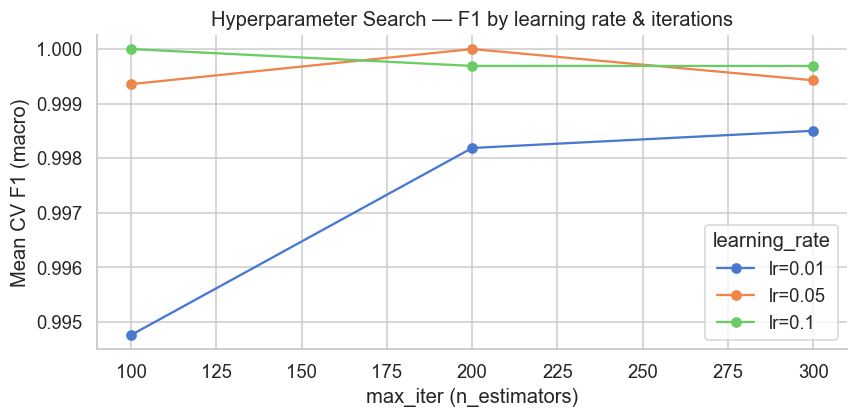


Top-5 parameter combinations:
 learning_rate  max_iter  max_depth  mean_F1   std_F1
          0.05       200          3 1.000000 0.000000
          0.10       100          3 1.000000 0.000000
          0.10       200          3 0.999690 0.000537
          0.10       300          3 0.999690 0.000537
          0.05       200          3 0.999666 0.000578


In [13]:
cv_results = pd.DataFrame(searcher.cv_results_)

pivot_data = cv_results.pivot_table(
    index="param_max_iter",
    columns="param_learning_rate",
    values="mean_test_score",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 4))
for lr in pivot_data.columns:
    ax.plot(pivot_data.index, pivot_data[lr], marker="o", label=f"lr={lr}")

ax.set_xlabel("max_iter (n_estimators)")
ax.set_ylabel("Mean CV F1 (macro)")
ax.set_title("Hyperparameter Search — F1 by learning rate & iterations")
ax.legend(title="learning_rate")
plt.tight_layout()
plt.show()

top5 = cv_results.nlargest(5, "mean_test_score")[
    ["param_learning_rate", "param_max_iter", "param_max_depth",
     "mean_test_score", "std_test_score"]
].reset_index(drop=True)
top5.columns = ["learning_rate", "max_iter", "max_depth", "mean_F1", "std_F1"]
print("\nTop-5 parameter combinations:")
print(top5.to_string(index=False))


In [14]:
best_model = searcher.best_estimator_

model_path = PROCESSED / "gbm_best.pkl"
try:
    PROCESSED.mkdir(parents=True, exist_ok=True)
    joblib.dump(best_model, model_path)
    print(f"Best model saved → {model_path}")
except Exception as exc:
    print(f"Could not save model ({exc}) — continuing without persistence.")


Best model saved → F:\AmphiLocator-ML\data\processed\gbm_best.pkl


---
## 7 — Evaluation on the Test Set

We assess the tuned model using four complementary metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall fraction of correct predictions |
| **Precision** | Of all predicted positive, what fraction truly are? |
| **Recall** | Of all true positives, what fraction did we catch? |
| **F1-score** | Harmonic mean of Precision & Recall |

We report **macro-averaged** scores (equal weight per class — important  
when classes are imbalanced) and display the **confusion matrix**.


In [15]:
if X_test is None or y_test is None:
    print("No test split available — evaluation skipped.")
else:
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print("=" * 50)
    print("TEST SET PERFORMANCE")
    print("=" * 50)
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision (macro) : {prec:.4f}")
    print(f"  Recall    (macro) : {rec:.4f}")
    print(f"  F1        (macro) : {f1:.4f}")
    print(f"  F1     (weighted) : {f1_weighted:.4f}")
    print("=" * 50)

    class_names = [str(c) for c in sorted(y_test.unique())]
    print("\nPer-class Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


TEST SET PERFORMANCE
  Accuracy          : 1.0000
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1        (macro) : 1.0000
  F1     (weighted) : 1.0000

Per-class Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00       339
           2       1.00      1.00      1.00        40
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       172
           5       1.00      1.00      1.00       109
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00       118
           8       1.00      1.00      1.00        64

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



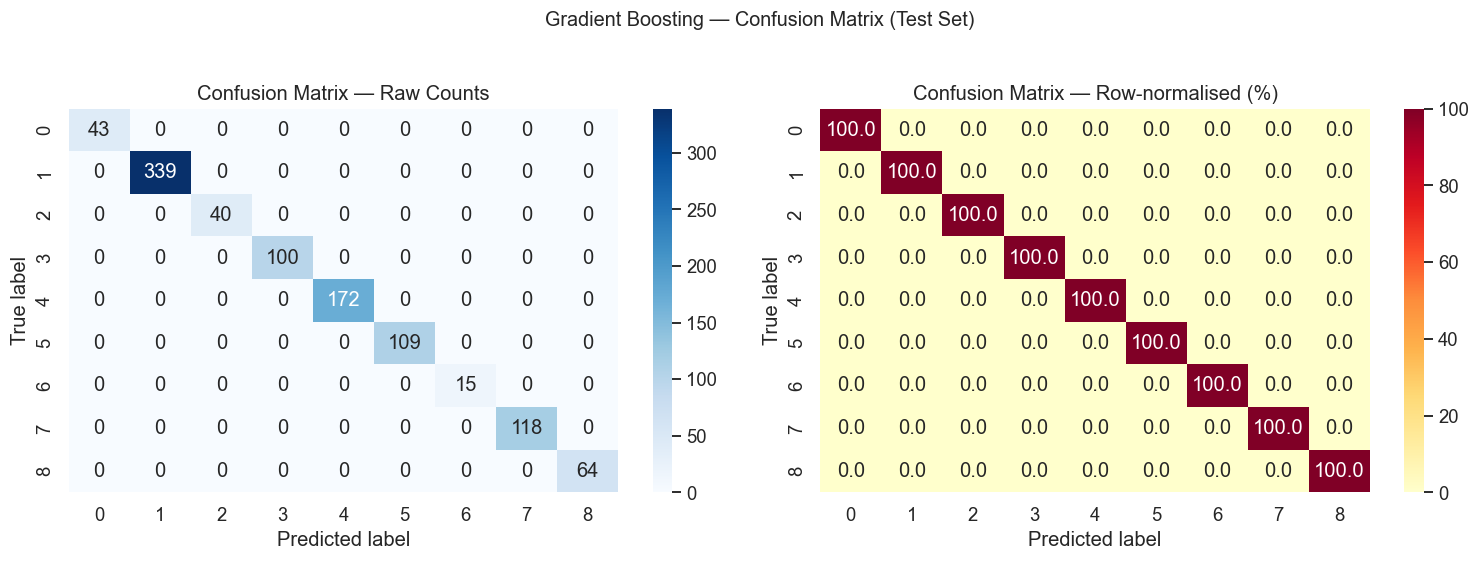

In [16]:
if X_test is not None and y_test is not None:
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Confusion Matrix — Raw Counts")
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title("Confusion Matrix — Row-normalised (%)")
    axes[1].set_xlabel("Predicted label")
    axes[1].set_ylabel("True label")

    plt.suptitle("Gradient Boosting — Confusion Matrix (Test Set)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


---
## 8 — Cross-Validation

Cross-validation gives a **more reliable performance estimate** than a  
single train/test split by averaging over multiple held-out folds.  
We re-run CV using the best hyperparameters found in Section 6.

A low standard deviation across folds indicates a stable model.


In [17]:
print("Running 5-fold cross-validation …")

cv_strategy_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=cv_strategy_eval,
    scoring="f1_macro",
    n_jobs=-1,
)

print(f"\nFold F1 (macro) scores : {np.round(cv_scores, 4)}")
print(f"Mean  ± Std            : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Min / Max              : {cv_scores.min():.4f} / {cv_scores.max():.4f}")


Running 5-fold cross-validation …

Fold F1 (macro) scores : [1.     1.     1.     0.9971 1.    ]
Mean  ± Std            : 0.9994 ± 0.0011
Min / Max              : 0.9971 / 1.0000


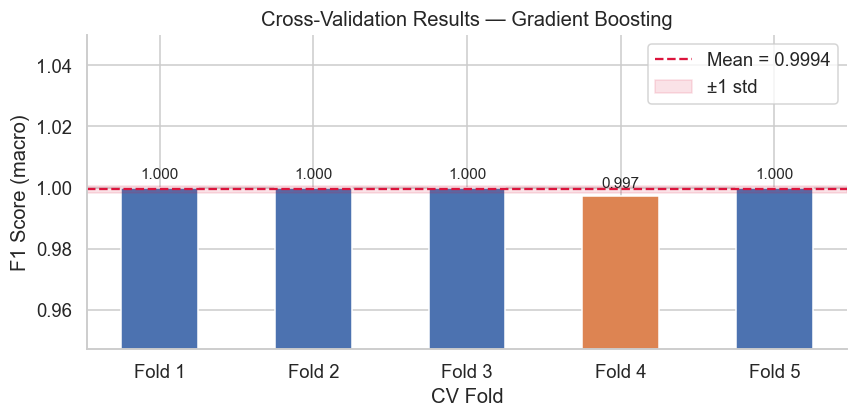

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
bar_colors  = ["#4C72B0" if s >= cv_scores.mean() else "#DD8452" for s in cv_scores]

bars = ax.bar(fold_labels, cv_scores, color=bar_colors, width=0.5, edgecolor="white")
ax.axhline(cv_scores.mean(), color="crimson", linestyle="--", linewidth=1.5,
           label=f"Mean = {cv_scores.mean():.4f}")
ax.axhspan(cv_scores.mean() - cv_scores.std(),
           cv_scores.mean() + cv_scores.std(),
           alpha=0.12, color="crimson", label="±1 std")

for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{score:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_ylim(max(0, cv_scores.min() - 0.05), min(1.05, cv_scores.max() + 0.06))
ax.set_xlabel("CV Fold")
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Cross-Validation Results — Gradient Boosting")
ax.legend()
plt.tight_layout()
plt.show()


---
## 9 — Feature Importance (Permutation-Based)

We use **permutation importance**: for each feature we randomly shuffle its  
values and measure the drop in F1.  A large drop → the feature is important.

This approach is **model-agnostic** and reflects true predictive value on  
the test set, unlike split-gain importance which can be biased toward  
high-cardinality features.


In [19]:
if X_test is not None and y_test is not None:
    print("Computing permutation importance (n_repeats=15) …")
    perm_result = permutation_importance(
        best_model, X_test, y_test,
        n_repeats=15, random_state=RANDOM_STATE,
        scoring="f1_macro", n_jobs=-1,
    )

    feat_imp = (
        pd.DataFrame({
            "feature":    X_test.columns,
            "importance": perm_result.importances_mean,
            "std":        perm_result.importances_std,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop-20 features by permutation importance:")
    print(feat_imp.head(20).to_string(index=False))
else:
    print("Test set not available — skipping permutation importance.")
    feat_imp = None


Computing permutation importance (n_repeats=15) …

Top-20 features by permutation importance:
            feature  importance      std
           hour_sin    0.232896 0.011039
       dist_Amphi_5    0.166218 0.010560
         is_outside    0.125344 0.007685
           hour_cos    0.041731 0.004405
       seat_zone_id    0.013245 0.002948
       dist_Amphi_2    0.006309 0.001426
           has_seat    0.005866 0.000606
       dist_Amphi_3    0.000848 0.000569
dist_Amphi_5_scaled    0.000000 0.000000
      dist_2nd_sqrt    0.000000 0.000000
  dist_nearest_sqrt    0.000000 0.000000
dist_Amphi_1_scaled    0.000000 0.000000
dist_Amphi_2_scaled    0.000000 0.000000
dist_Amphi_3_scaled    0.000000 0.000000
dist_Amphi_4_scaled    0.000000 0.000000
dist_Amphi_6_scaled    0.000000 0.000000
 dist_gap_x_highacc    0.000000 0.000000
dist_Amphi_7_scaled    0.000000 0.000000
dist_Amphi_8_scaled    0.000000 0.000000
sample_count_scaled    0.000000 0.000000


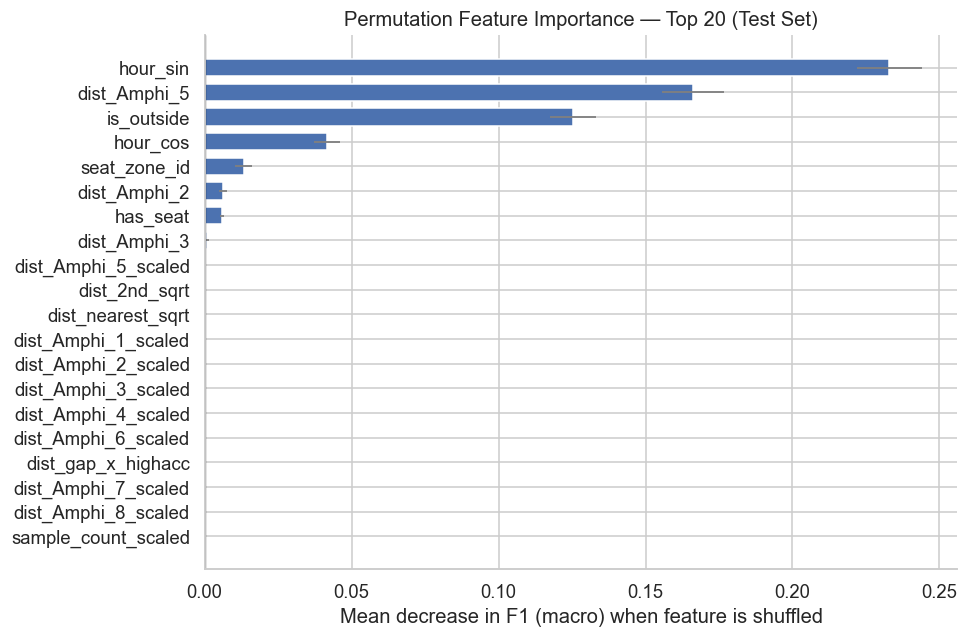

In [20]:
if feat_imp is not None:
    top20 = feat_imp.head(20).iloc[::-1]

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(top20["feature"], top20["importance"],
                   xerr=top20["std"], color="#4C72B0",
                   error_kw={"elinewidth": 1.2, "ecolor": "grey"},
                   height=0.7)
    ax.set_xlabel("Mean decrease in F1 (macro) when feature is shuffled")
    ax.set_title("Permutation Feature Importance — Top 20 (Test Set)")
    ax.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()


In [21]:
print("=" * 60)
print("GRADIENT BOOSTING — FINAL MODEL SUMMARY")
print("=" * 60)
print(f"  Best hyperparameters : {searcher.best_params_}")
print(f"  Best CV F1 (macro)   : {searcher.best_score_:.4f}")
if X_test is not None and y_test is not None:
    y_pred_final = best_model.predict(X_test)
    print(f"  Test Accuracy        : {accuracy_score(y_test, y_pred_final):.4f}")
    print(f"  Test F1  (macro)     : {f1_score(y_test, y_pred_final, average='macro', zero_division=0):.4f}")
    print(f"  Test F1 (weighted)   : {f1_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"  CV Mean F1 ± Std     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Number of features   : {len(FEATURES)}")
print(f"  Number of classes    : {n_classes}")
print("=" * 60)


GRADIENT BOOSTING — FINAL MODEL SUMMARY
  Best hyperparameters : {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 50}
  Best CV F1 (macro)   : 1.0000
  Test Accuracy        : 1.0000
  Test F1  (macro)     : 1.0000
  Test F1 (weighted)   : 1.0000
  CV Mean F1 ± Std     : 0.9994 ± 0.0011
  Number of features   : 44
  Number of classes    : 9
